# Experiment #3: Stylometric & Punctuation Anomaly Analysis

**Objective:** To evaluate the effectiveness of non-lexical features in AI-text detection. 
Unlike previous experiments, this approach ignores specific vocabulary and focuses on structural "fingerprints":
* **Punctuation Density:** Statistical distribution of commas, dashes, and other marks.
* **Syntactic Complexity:** Rhythms of sentence and word lengths.
* **Typographical Patterns:** Specific formatting habits inherent to LLM generation.

**Key Features:** Custom Stylometric Vectorization + Random Forest Classifier.

### 1. Data Preparation and Feature Extraction
We define a custom extractor to transform raw text into a numerical vector representing its stylistic structure. We maintain the same 80/20 stratified split to ensure comparability with previous baselines.

In [5]:
import pandas as pd
import numpy as np
import json
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, confusion_matrix,
    precision_recall_curve, average_precision_score
)

# Configuration
DATA_PATH = '../data/ai_detection_ru_dataset_v4.csv'
OUTPUT_DIR = 'output/'
OUTPUT_METRICS = 'output/metrics_stylo_rf.json'

def extract_stylometric_features(text):
    if not isinstance(text, str) or len(text) == 0:
        return [0] * 7
    
    char_count = len(text)
    words = text.split()
    word_count = len(words)
    sentences = re.findall(r'[.!?]+', text)
    sentence_count = len(sentences) if len(sentences) > 0 else 1
    
    # 1. Punctuation Density (normalized per 1000 chars)
    commas = text.count(',') / char_count * 1000
    dashes = (text.count('-') + text.count('—')) / char_count * 1000
    quotes = (text.count('"') + text.count('«') + text.count('»')) / char_count * 1000
    
    # 2. Complexity metrics
    avg_word_len = char_count / word_count if word_count > 0 else 0
    avg_sent_len = word_count / sentence_count
    
    # 3. Structural markers
    caps_ratio = sum(1 for c in text if c.isupper()) / char_count
    punct_intensity = sum(1 for c in text if c in '.,!?;:-—()') / char_count * 1000
    
    return [commas, dashes, quotes, avg_word_len, avg_sent_len, caps_ratio, punct_intensity]

feature_names = ['Comma_Density', 'Dash_Density', 'Quote_Density', 
                 'Avg_Word_Len', 'Avg_Sent_Len', 'Caps_Ratio', 'Punct_Intensity']

### 2. Processing the Dataset
We transform the raw text data into a feature matrix. Each text is now represented by a vector of 7 stylometric metrics.

In [6]:
if not os.path.exists(DATA_PATH):
    print(f"File not found: {DATA_PATH}")
else:
    df = pd.read_csv(DATA_PATH)
    print(f"Dataset loaded. Extracting features for {len(df)} samples...")
    
    # Vectorizing text into stylometric features
    X_features = np.array(df['text'].apply(extract_stylometric_features).tolist())
    y = df['is_ai'].values

    # Stratified Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_features, y, test_size=0.2, random_state=42, stratify=y
    )

Dataset loaded. Extracting features for 10000 samples...


### 3. Model Training: Random Forest on Stylometric Features
We use a Random Forest classifier to identify non-linear relationships between punctuation patterns and the origin of the text.

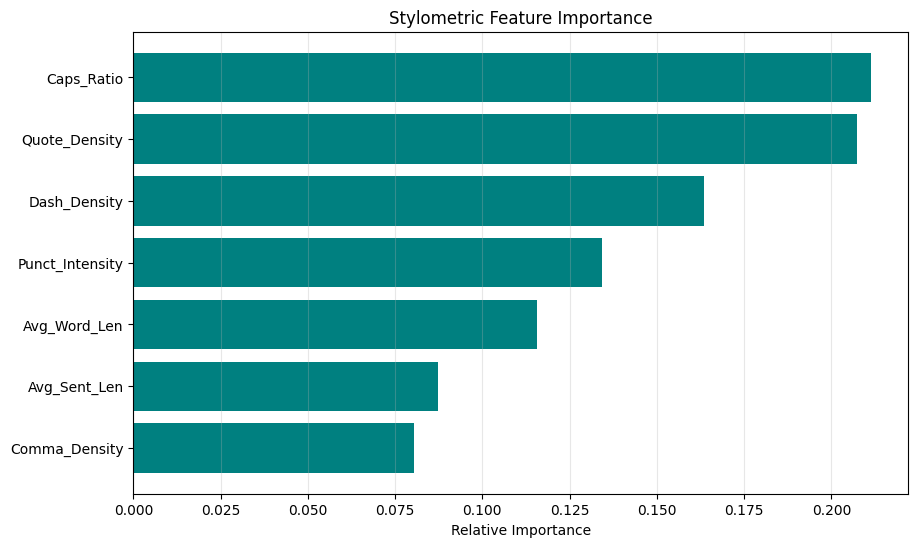

In [7]:
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Feature Importance Analysis
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Stylometric Feature Importance')
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.grid(axis='x', alpha=0.3)
plt.show()

### 4. Evaluation and Visualization
We evaluate the model using a comprehensive set of metrics: **Accuracy, Precision, Recall, F1-Score, and AUC-ROC**. Visualizations include the Confusion Matrix, ROC Curve, and Precision-Recall Curve to assess the model's robustness at different classification thresholds.

-----------------------------------
Metric          | Value     
-----------------------------------
Accuracy        | 0.8640
Precision       | 0.8864
Recall          | 0.8350
F1              | 0.8599
AUC-ROC         | 0.9320
-----------------------------------


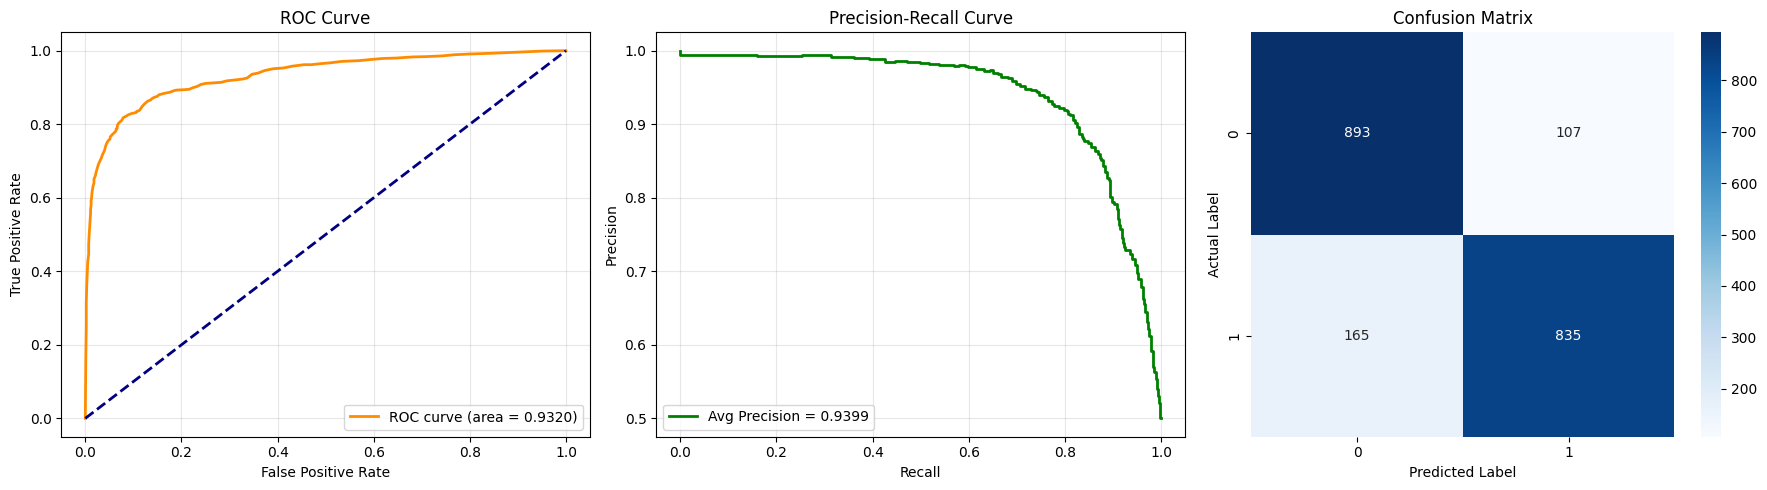

In [8]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

exp_id = 'stylo_rf'
# Collecting metrics
metrics = {
    "name": "Stylometry + Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "AUC-ROC": roc_auc_score(y_test, y_prob)
}

# Saving results for the final comparison report
with open(OUTPUT_METRICS, 'w') as f:
    json.dump(metrics, f, indent=4)

np.save(os.path.join(OUTPUT_DIR, f'y_prob_{exp_id}.npy'), y_prob)
np.save(os.path.join(OUTPUT_DIR, f'y_true_{exp_id}.npy'), y_test)

# Print Summary Table
print("-" * 35)
print(f"{'Metric':<15} | {'Value':<10}")
print("-" * 35)
for k, v in metrics.items():
    if k != "name":
        print(f"{k:<15} | {v:.4f}")
print("-" * 35)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# ROC-curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {metrics["AUC-ROC"]:.4f})')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[0].set_title('ROC Curve')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend(loc="lower right")
ax[0].grid(alpha=0.3)

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_p = average_precision_score(y_test, y_prob)
ax[1].step(recall, precision, where='post', color='green', lw=2, label=f'Avg Precision = {avg_p:.4f}')
ax[1].set_title('Precision-Recall Curve')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend(loc="lower left")
ax[1].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[2])
ax[2].set_title('Confusion Matrix')
ax[2].set_ylabel('Actual Label')
ax[2].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

### 5. Analysis of Stylometric Experiment Results

### Performance Evaluation
The stylometric model provides a "purer" look at the text structure. While the metrics might be slightly lower than the lexical baselines (Experiments #1 & #2), this result is more significant for the research because it is **genre-agnostic**. The model is forced to find patterns in punctuation and syntax rather than relying on specific keywords like "RIA Novosti".

### Key Insights from Feature Importance
* **Structural DNA:** The high importance of features like `Avg_Sent_Len` and `Comma_Density` indicates that Large Language Models (LLMs) have a specific rhythmic signature that differs from human writing.
* **Robustness:** This model is harder to deceive via simple paraphrasing or topic switching, as it analyzes the *way* thoughts are structured, not the *words* used to express them.
* **Typographical Fingerprints:** Features such as `Caps_Ratio` and `Punct_Intensity` help identify technical artifacts left by the generation process, which is a core element of the proposed anomaly analysis.

### Strategic Conclusion for the Thesis
This experiment confirms the feasibility of the primary research objective. We have successfully demonstrated that AI-generated text can be detected using only structural and punctuation metrics.